# JS05: Lab 2
## Klasifikasi Naive Bayes dengan data dummy

## Langkah 1: Membuat dataset dummy

In [1]:
import numpy as np
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=30,
    n_features=2,
    n_classes=2,
    n_informative=2,
    n_redundant=0,
    n_repeated=0,
    shuffle=False,
)
X = np.absolute(X)
X = np.round(X, 2) * 100
X = X.astype(int)
print(X)
print(y)

[[181 405]
 [143 135]
 [ 62  72]
 [ 44  63]
 [ 75 155]
 [ 28 211]
 [ 17  18]
 [ 79 135]
 [ 94  44]
 [238  66]
 [155 187]
 [ 71 119]
 [120 113]
 [ 54  63]
 [ 19  46]
 [176 149]
 [ 87 111]
 [ 96 105]
 [164  46]
 [140  88]
 [220  25]
 [ 77 114]
 [ 95 110]
 [102  81]
 [ 83 158]
 [ 84 118]
 [110  51]
 [ 96 100]
 [ 88 114]
 [126  83]]
[0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 1 1 1 1 1 1 1]


## Langkah 2: Membuat DataFrame

In [2]:
import pandas as pd

y_new = y.reshape(len(y), 1)
data = np.concatenate((X, y_new), axis=1)
nama_kolom = ["Fitur 1", "Fitur 2", "Label"]
df = pd.DataFrame(data, columns=nama_kolom)
df.head()

,Fitur 1,Fitur 2,Label
0,181,405,0
1,143,135,0
2,62,72,0
3,44,63,0
4,75,155,0


## Langkah 3: Memberi nama label

In [3]:
labels = {1: "Kelas A", 0: "Kelas B"}
df_label = df.copy()
df_label["Label"] = df_label["Label"].map(labels)
df_label.head()

,Fitur 1,Fitur 2,Label
0,181,405,Kelas B
1,143,135,Kelas B
2,62,72,Kelas B
3,44,63,Kelas B
4,75,155,Kelas B


## Langkah 4: Visualisasi data

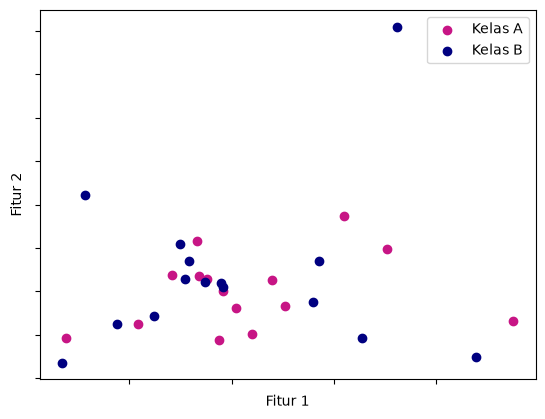

In [4]:
import matplotlib.pyplot as plt

colors = {"class_a": "MediumVioletRed", "class_b": "Navy"}
gb = df_label.groupby("Label")
class_a = gb.get_group("Kelas A")
class_b = gb.get_group("Kelas B")
plt.scatter(class_a["Fitur 1"], class_a["Fitur 2"], c=colors["class_a"])
plt.scatter(class_b["Fitur 1"], class_b["Fitur 2"], c=colors["class_b"])
plt.xlabel("Fitur 1")
plt.ylabel("Fitur 2")
plt.legend(["Kelas A", "Kelas B"])
plt.gca().axes.xaxis.set_ticklabels([])
plt.gca().axes.yaxis.set_ticklabels([])
plt.show()

## Langkah 5: Model Multinomial Naive Bayes

In [5]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

mnb = MultinomialNB()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=30
)
mnb.fit(X_train, y_train)
y_train_pred = mnb.predict(X_train)
y_test_pred = mnb.predict(X_test)
acc_train = accuracy_score(y_train, y_train_pred)
acc_test = accuracy_score(y_test, y_test_pred)
print(f"Hasil akurasi data train: {acc_train}")
print(f"Hasil akurasi data test: {acc_test}")

Hasil akurasi data train: 0.6190476190476191
Hasil akurasi data test: 0.5555555555555556


## Langkah 6: Model Gaussian Naive Bayes

In [6]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_train_pred_gnb = gnb.predict(X_train)
y_test_pred_gnb = gnb.predict(X_test)
acc_train_gnb = accuracy_score(y_train, y_train_pred_gnb)
acc_test_gnb = accuracy_score(y_test, y_test_pred_gnb)
print(f"Hasil akurasi data train (Gaussian): {acc_train_gnb}")
print(f"Hasil akurasi data test (Gaussian): {acc_test_gnb}")

Hasil akurasi data train (Gaussian): 0.6666666666666666
Hasil akurasi data test (Gaussian): 0.2222222222222222
